<a href="https://colab.research.google.com/github/Rogerio97/MLP-Approach-for-Predicting-Water-Level-in-the-Rio-Negro-Basin/blob/main/MLP_Approach_for_Predicting_Water_Level_in_the_Rio_Negro_Basin_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLP Approach for Predicting Water Levels in the Rio Negro Basin**

---
Rogério Costa de Oliveira Junior

```
in = 'Bonete_level'(t1), 'Manuel_Díaz_level'(t1), 'Cuñapirú_level'(t1)      
     'Mazangano_level'(t1), 'Coelho_level'(t1), 'Paso_de_las_Toscas_level'(t1),
     'Aguiar_level'(t1),'Laguna_I_level'(t1), 'Laguna_II_level'(t1),
     'Pereira_level'(t1), 'San_Gregorio_level'(t1), 'Paso_de_los_Toros_level'(t1),
     'Salsipuedes_level'(t1), 'Sarandi_del_Yi_level'(t1), 'Durazno_level'(t1),
     'Polanco_level'(t1), 'Lugo_level'(t1), 'Mercedes_level'(t1)

out = 'Mercedes_level'(t2)

```

##Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import seaborn as sns
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # :´(
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

#Visualizing Data

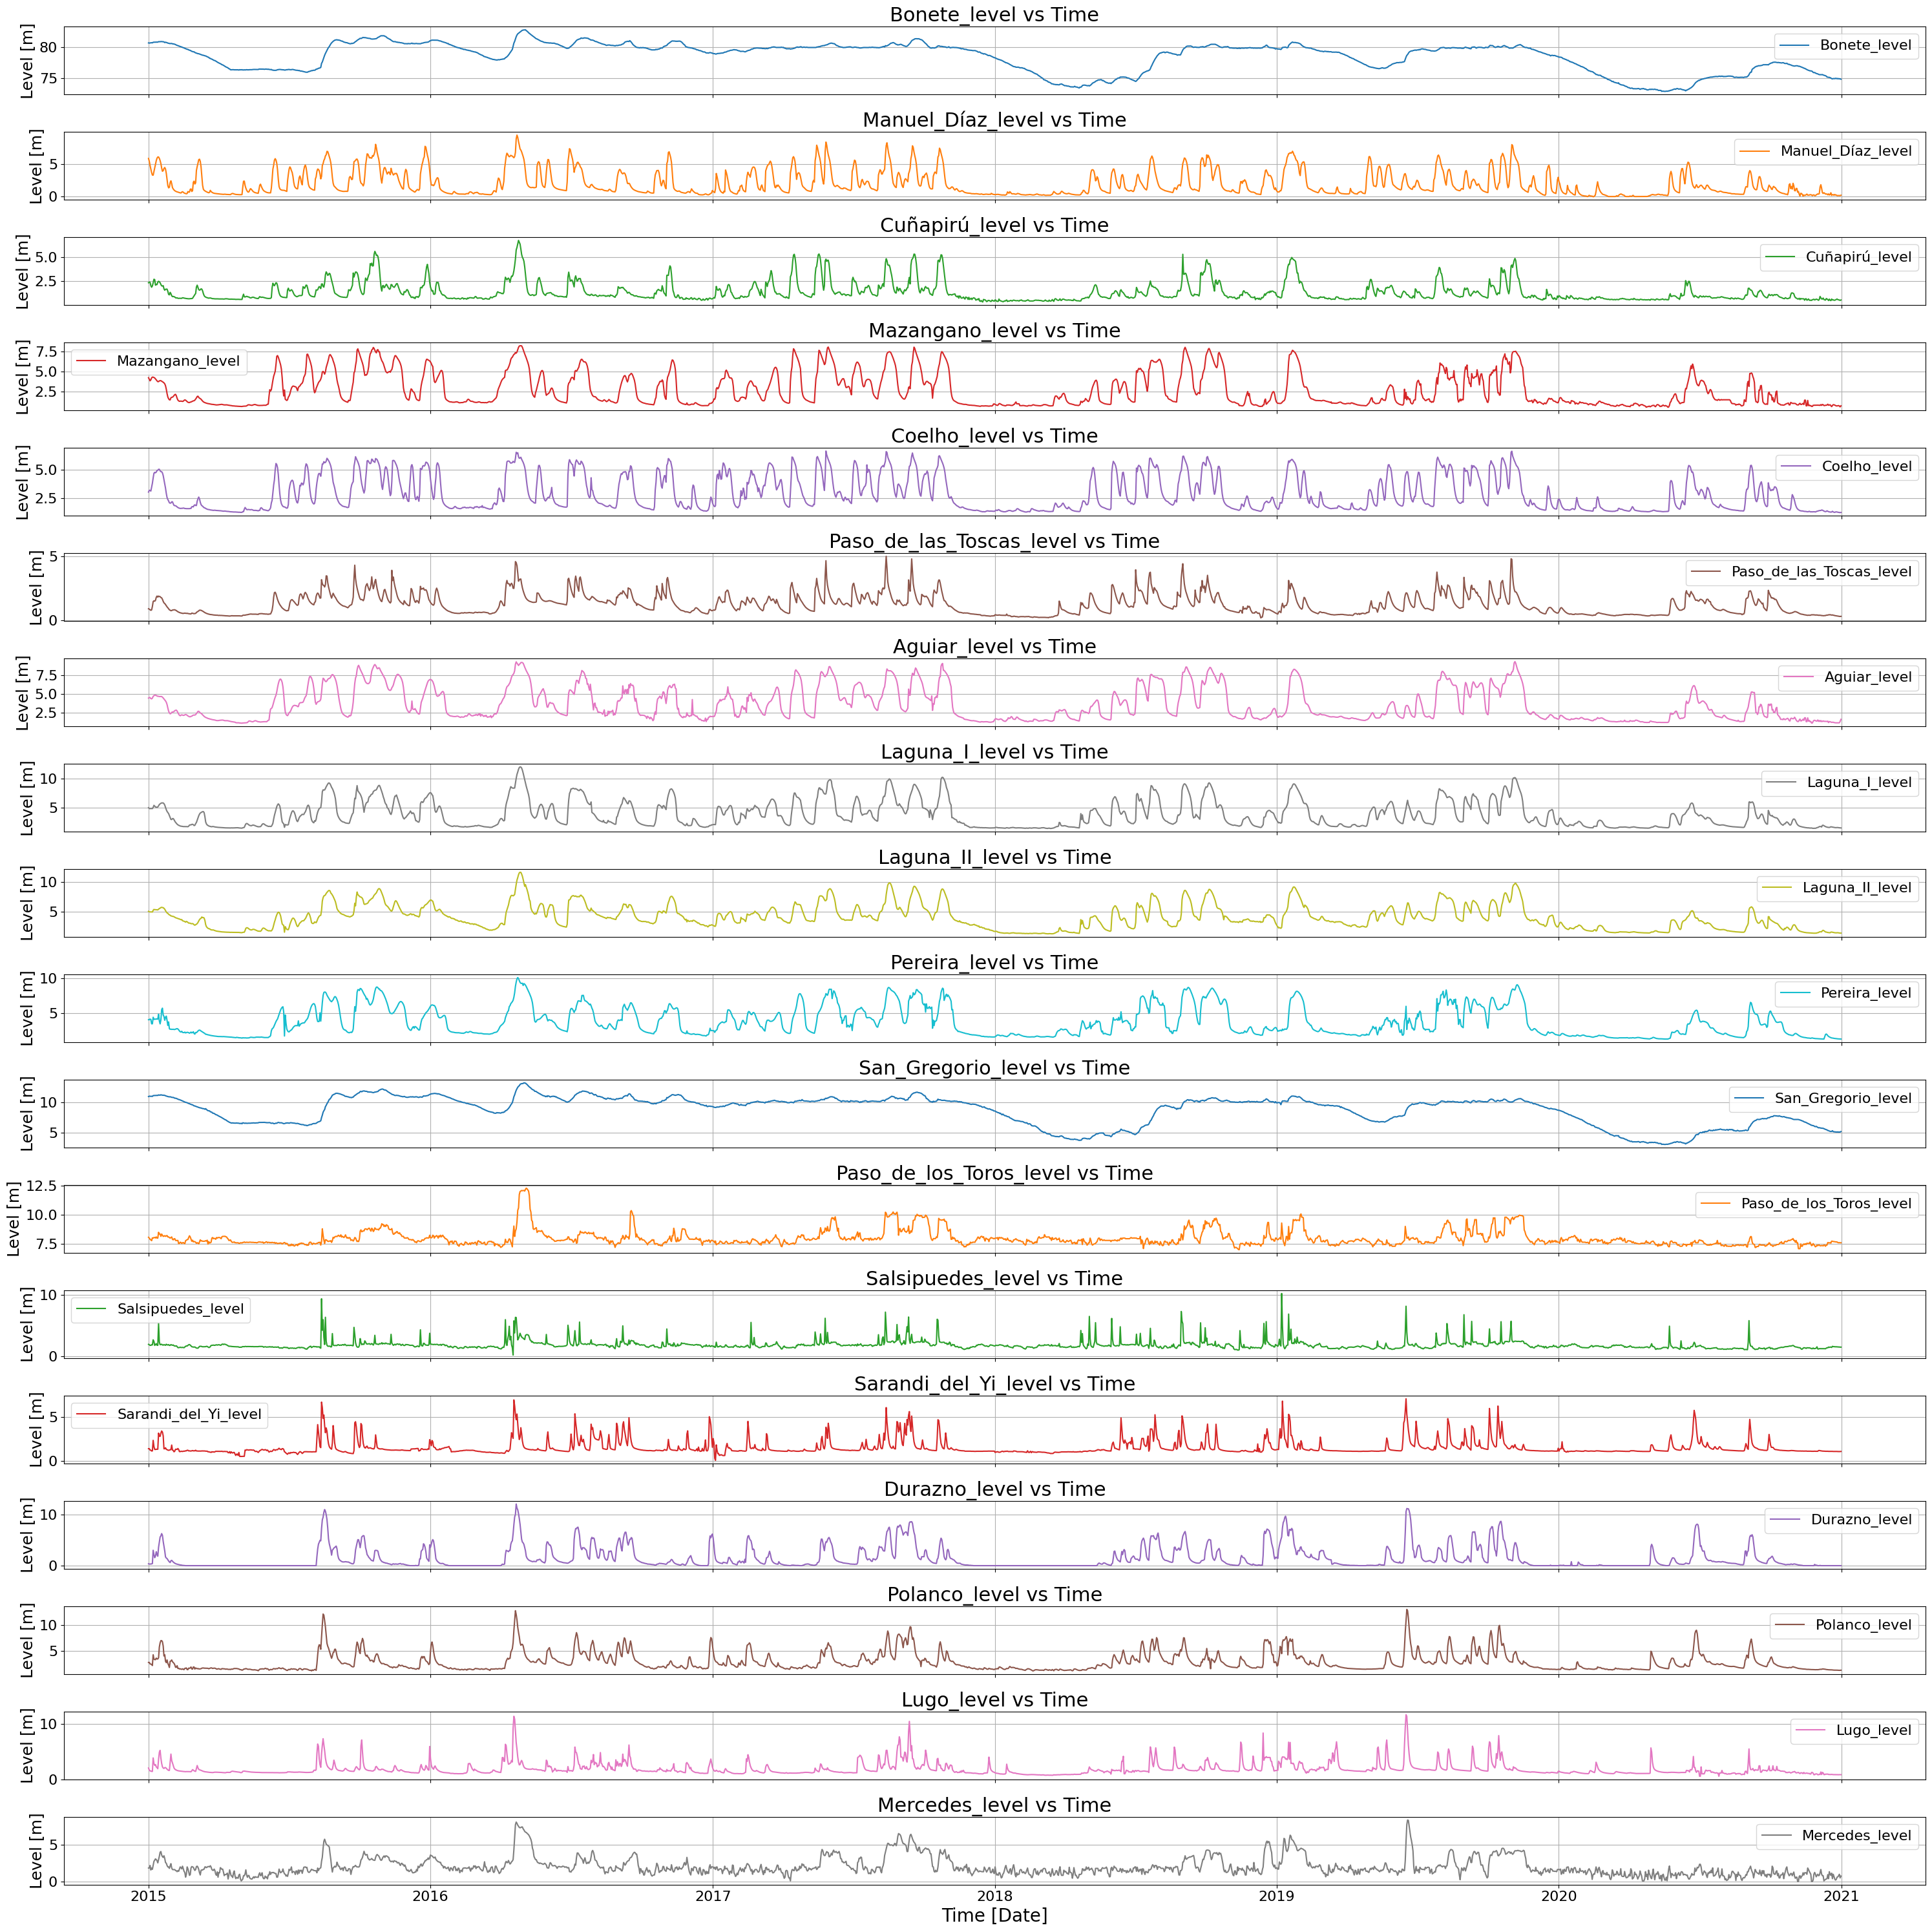

In [2]:
# Load data from the .csv file into a pandas DataFrame
data = pd.read_csv('/content/Rio Negro_level - date_18.csv')

# Convert the 'date' column to datetime format, interpreting day first (e.g., DD/MM/YYYY)
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

# List of column names representing water levels at different locations
columns = [
    'Bonete_level', 'Manuel_Díaz_level', 'Cuñapirú_level', 'Mazangano_level',
    'Coelho_level', 'Paso_de_las_Toscas_level', 'Aguiar_level',
    'Laguna_I_level', 'Laguna_II_level', 'Pereira_level',
    'San_Gregorio_level', 'Paso_de_los_Toros_level',
    'Salsipuedes_level', 'Sarandi_del_Yi_level', 'Durazno_level',
    'Polanco_level', 'Lugo_level', 'Mercedes_level'
]

# Configure the plot with 18 rows (one per location) and 1 column, with a large figure size
fig, axes = plt.subplots(len(columns), 1, figsize=(30, 30), sharex=True)

# Loop through each column (location) and its corresponding subplot axis
for i, column in enumerate(columns):
    # Plot the time series (date vs. level) with a unique color (cycling through default colors)
    axes[i].plot(data['date'], data[column], label=f'{column}', color='C'+str(i % 10))

    # Set subplot title with larger font
    axes[i].set_title(f'{column} vs Time', fontsize=22)

    # Label the Y-axis as "Level [m]" with larger font
    axes[i].set_ylabel('Level [m]', fontsize=18)

    # Add a legend with larger font
    axes[i].legend(fontsize=16)

    # Enable grid lines
    axes[i].grid(True)

    # Increase tick label font size for both X and Y axes
    axes[i].tick_params(axis='both', which='major', labelsize=16)

# Final adjustments:
# Set the shared X-axis label with larger font
plt.xlabel('Time [Date]', fontsize=20)

# Adjust subplot spacing to prevent overlap
plt.tight_layout()

# Display the full figure
plt.show()

## Correlation Matrix

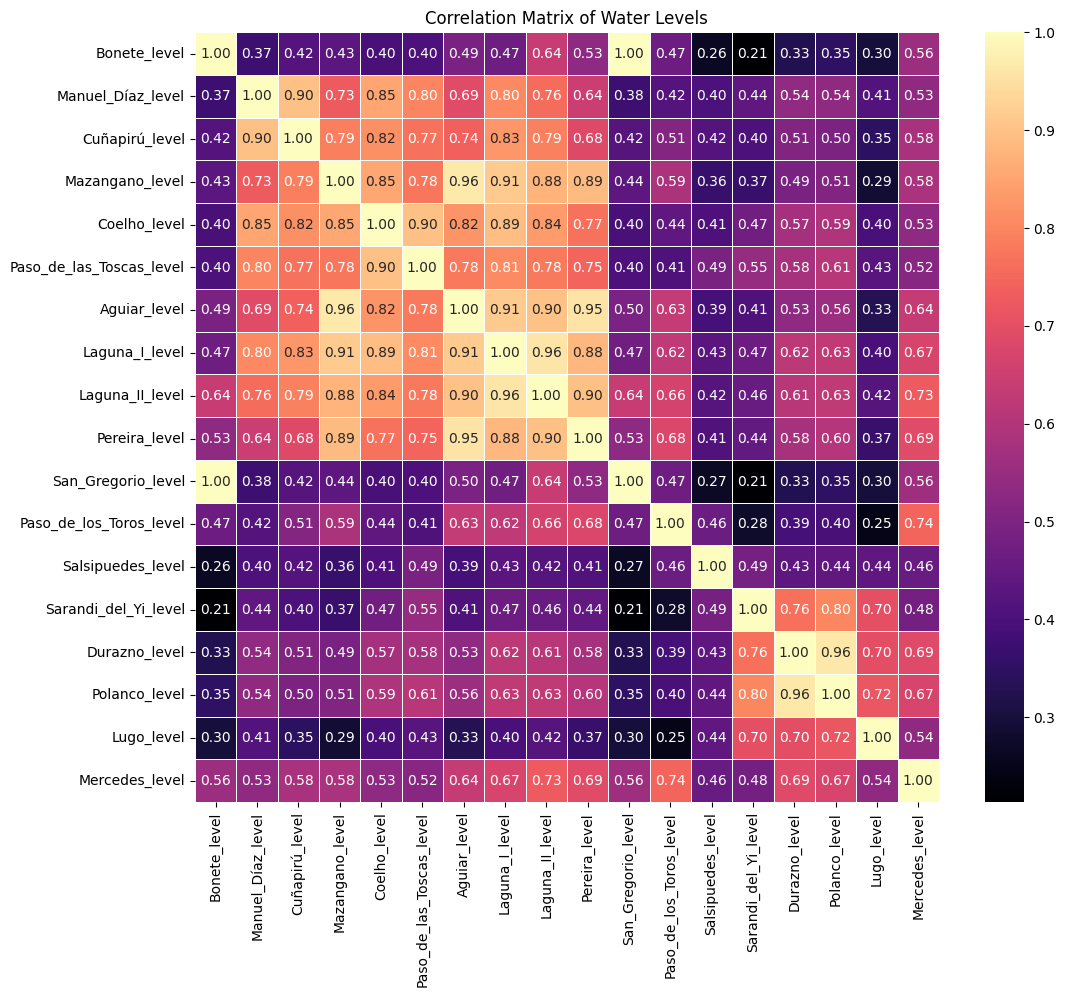

In [3]:
# Load data from the .csv file into a pandas DataFrame
data = pd.read_csv('/content/Rio Negro_level - date_18.csv')  # Path to the CSV file containing water level data

# Define a list of column names representing water levels at different measurement locations
columns = [
    'Bonete_level', 'Manuel_Díaz_level', 'Cuñapirú_level', 'Mazangano_level',
    'Coelho_level', 'Paso_de_las_Toscas_level', 'Aguiar_level',
    'Laguna_I_level', 'Laguna_II_level', 'Pereira_level',
    'San_Gregorio_level', 'Paso_de_los_Toros_level',
    'Salsipuedes_level', 'Sarandi_del_Yi_level', 'Durazno_level',
    'Polanco_level', 'Lugo_level', 'Mercedes_level'
]

# Calculate the Pearson correlation matrix for the selected water level columns
# (Measures linear relationships between -1 [anti-correlation] and +1 [perfect correlation])
corr_matrix = data[columns].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))  # Set figure size for better readability

# Create heatmap with:
# - Annotated correlation values (annot=True)
# - 'magma' color scheme (alternatives commented: inferno, viridis, coolwarm)
# - Values formatted to 2 decimal places (fmt='.2f')
# - Thin white lines between cells (linewidths=0.5)
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt='.2f', linewidths=0.5)

# Add a descriptive title
plt.title('Correlation Matrix of Water Levels')

# Display the plot
plt.show()


## Visualizing Rivers case studies

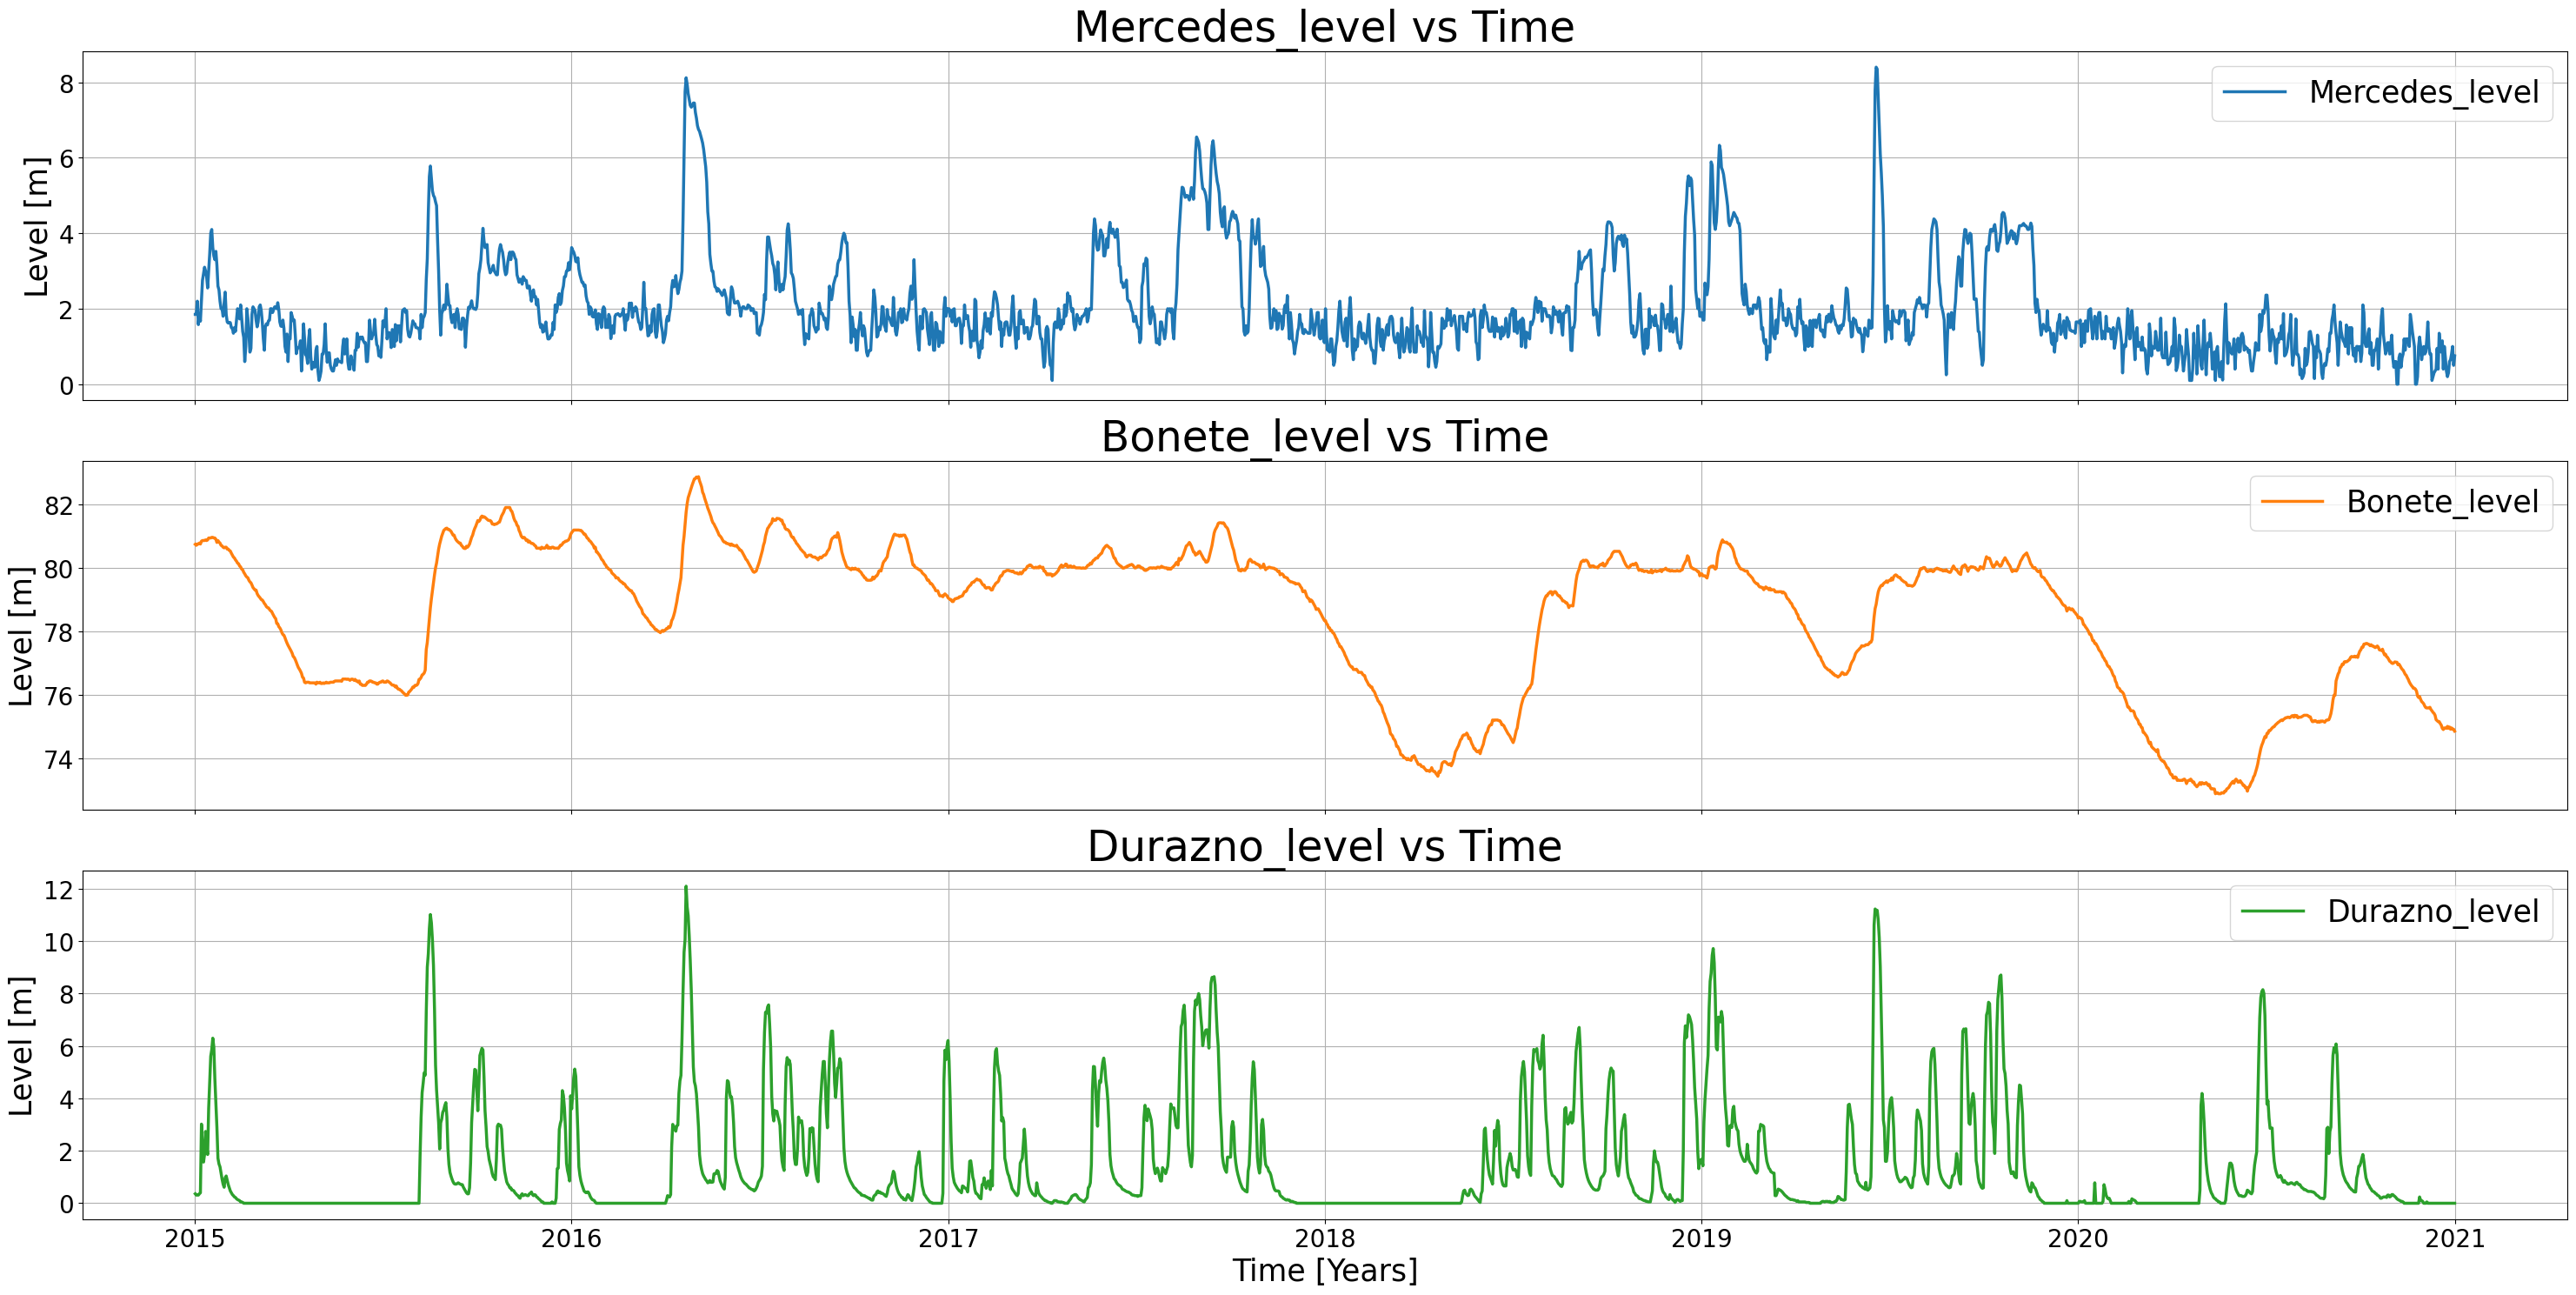

In [4]:
# Load data from the CSV file
data = pd.read_csv('/content/Rio Negro_level - date_18.csv')

# Convert the 'date' column to the correct datetime format
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

# Variable to select which columns will be plotted
columns_to_plot = ['Mercedes_level', 'Bonete_level', 'Durazno_level']

# Set the number of graphs based on the list size
num_graphs = len(columns_to_plot)

# Configure the plot with the required number of rows
fig, axes = plt.subplots(num_graphs, 1, figsize=(30, 5 * num_graphs), sharex=True)

# Ensure 'axes' is a list, even if there is only one graph
if num_graphs == 1:
    axes = [axes]

# Iterate over each selected column and corresponding axis
for i, column in enumerate(columns_to_plot):
    axes[i].plot(
        data['date'],  # Use the 'date' column as the X-axis
        data[column],
        label=f'{column}',
        color=f'C{i % 10}',
        linewidth=2.5  # Adjust line thickness
    )
    axes[i].set_title(f'{column} vs Time', fontsize=35)  # Title size
    axes[i].set_ylabel('Level [m]', fontsize=25)         # Y-axis label size
    axes[i].legend(fontsize=25)                          # Legend size
    axes[i].grid(True)
    axes[i].tick_params(axis='both', which='major', labelsize=20)  # Increase axis number size

# Final adjustments
plt.xlabel('Time [Years]', fontsize=25)  # The X-axis now shows dates
plt.tight_layout()
plt.show()


# Data Preprocessing - Selected river

In [5]:
# Load data from CSV file into pandas DataFrame
data = pd.read_csv('/content/Rio Negro_level - date_18.csv')
# Remove 'days' and 'date' columns as they won't be used as features
data = data.drop(columns=['days', 'date'])

# Alternative: More aggressive column dropping (commented out for now)
# data = data.drop(columns=['days', 'date', 'Salsipuedes_level', 'Paso_de_los_Toros_level',
#                          'Sarandi_del_Yi_level', 'Polanco_level', 'Durazno_level',
#                          'Lugo_level', 'Mercedes_level'])

# Get list of available river level columns
available_rivers = data.columns

# User interface for river selection
print("Choose the river:")
# Display numbered list of available rivers
for idx, river in enumerate(available_rivers, start=1):
    print(f"{idx}. {river}")

# Get user input and convert to zero-based index
river_choice = int(input("Enter the number corresponding to the river: ")) - 1
selected_river = available_rivers[river_choice]
print(f"\nSelected river for prediction: {selected_river}")

# Prepare features (X) and target (y) for ML model
MLP_shift = 1  # Predict next day's value (1-day forecast horizon)
X = data.values[:-MLP_shift]  # All features except last MLP_shift rows
# Target is selected river's level shifted by MLP_shift days (next day's value)
y = data[selected_river].shift(-MLP_shift).dropna().values

# Calculate dataset split sizes
total_samples = len(X)
train_size = int(0.5 * total_samples)  # 50% for training
val_size = int(0.2 * total_samples)    # 20% for validation
test_size = total_samples - train_size - val_size  # Remaining 30% for testing

# Create dataset splits ensuring temporal consistency
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

# Initialize MinMaxScalers for feature normalization (range [0, 1])
scaler_X = MinMaxScaler()  # For features
scaler_y = MinMaxScaler()  # For target

# Normalize features
X_train = scaler_X.fit_transform(X_train)  # Fit and transform training data
X_val = scaler_X.transform(X_val)          # Transform validation data
X_test = scaler_X.transform(X_test)        # Transform test data
test_len = len(X_test)  # Store test set length for later use

# Normalize target variable
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Add dimension for model
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Print dataset information
print(f"\nSize of X_train: {X_train.shape}")
print(f"Size of X_val: {X_val.shape}")
print(f"Size of X_test: {X_test.shape}")

# Verify normalization ranges
print(f"X_train min: {X_train.min()}, max: {X_train.max()}")  # Should be ~0-1
print(f"y_train min: {y_train.min()}, max: {y_train.max()}")  # Should be ~0-1

Choose the river:
1. Bonete_level
2. Manuel_Díaz_level
3. Cuñapirú_level
4. Mazangano_level
5. Coelho_level
6. Paso_de_las_Toscas_level
7. Aguiar_level
8. Laguna_I_level
9. Laguna_II_level
10. Pereira_level
11. San_Gregorio_level
12. Paso_de_los_Toros_level
13. Salsipuedes_level
14. Sarandi_del_Yi_level
15. Durazno_level
16. Polanco_level
17. Lugo_level
18. Mercedes_level
Enter the number corresponding to the river: 18

Selected river for prediction: Mercedes_level

Size of X_train: torch.Size([1095, 18])
Size of X_val: torch.Size([438, 18])
Size of X_test: torch.Size([658, 18])
X_train min: 0.0, max: 1.0
y_train min: 0.0, max: 1.0


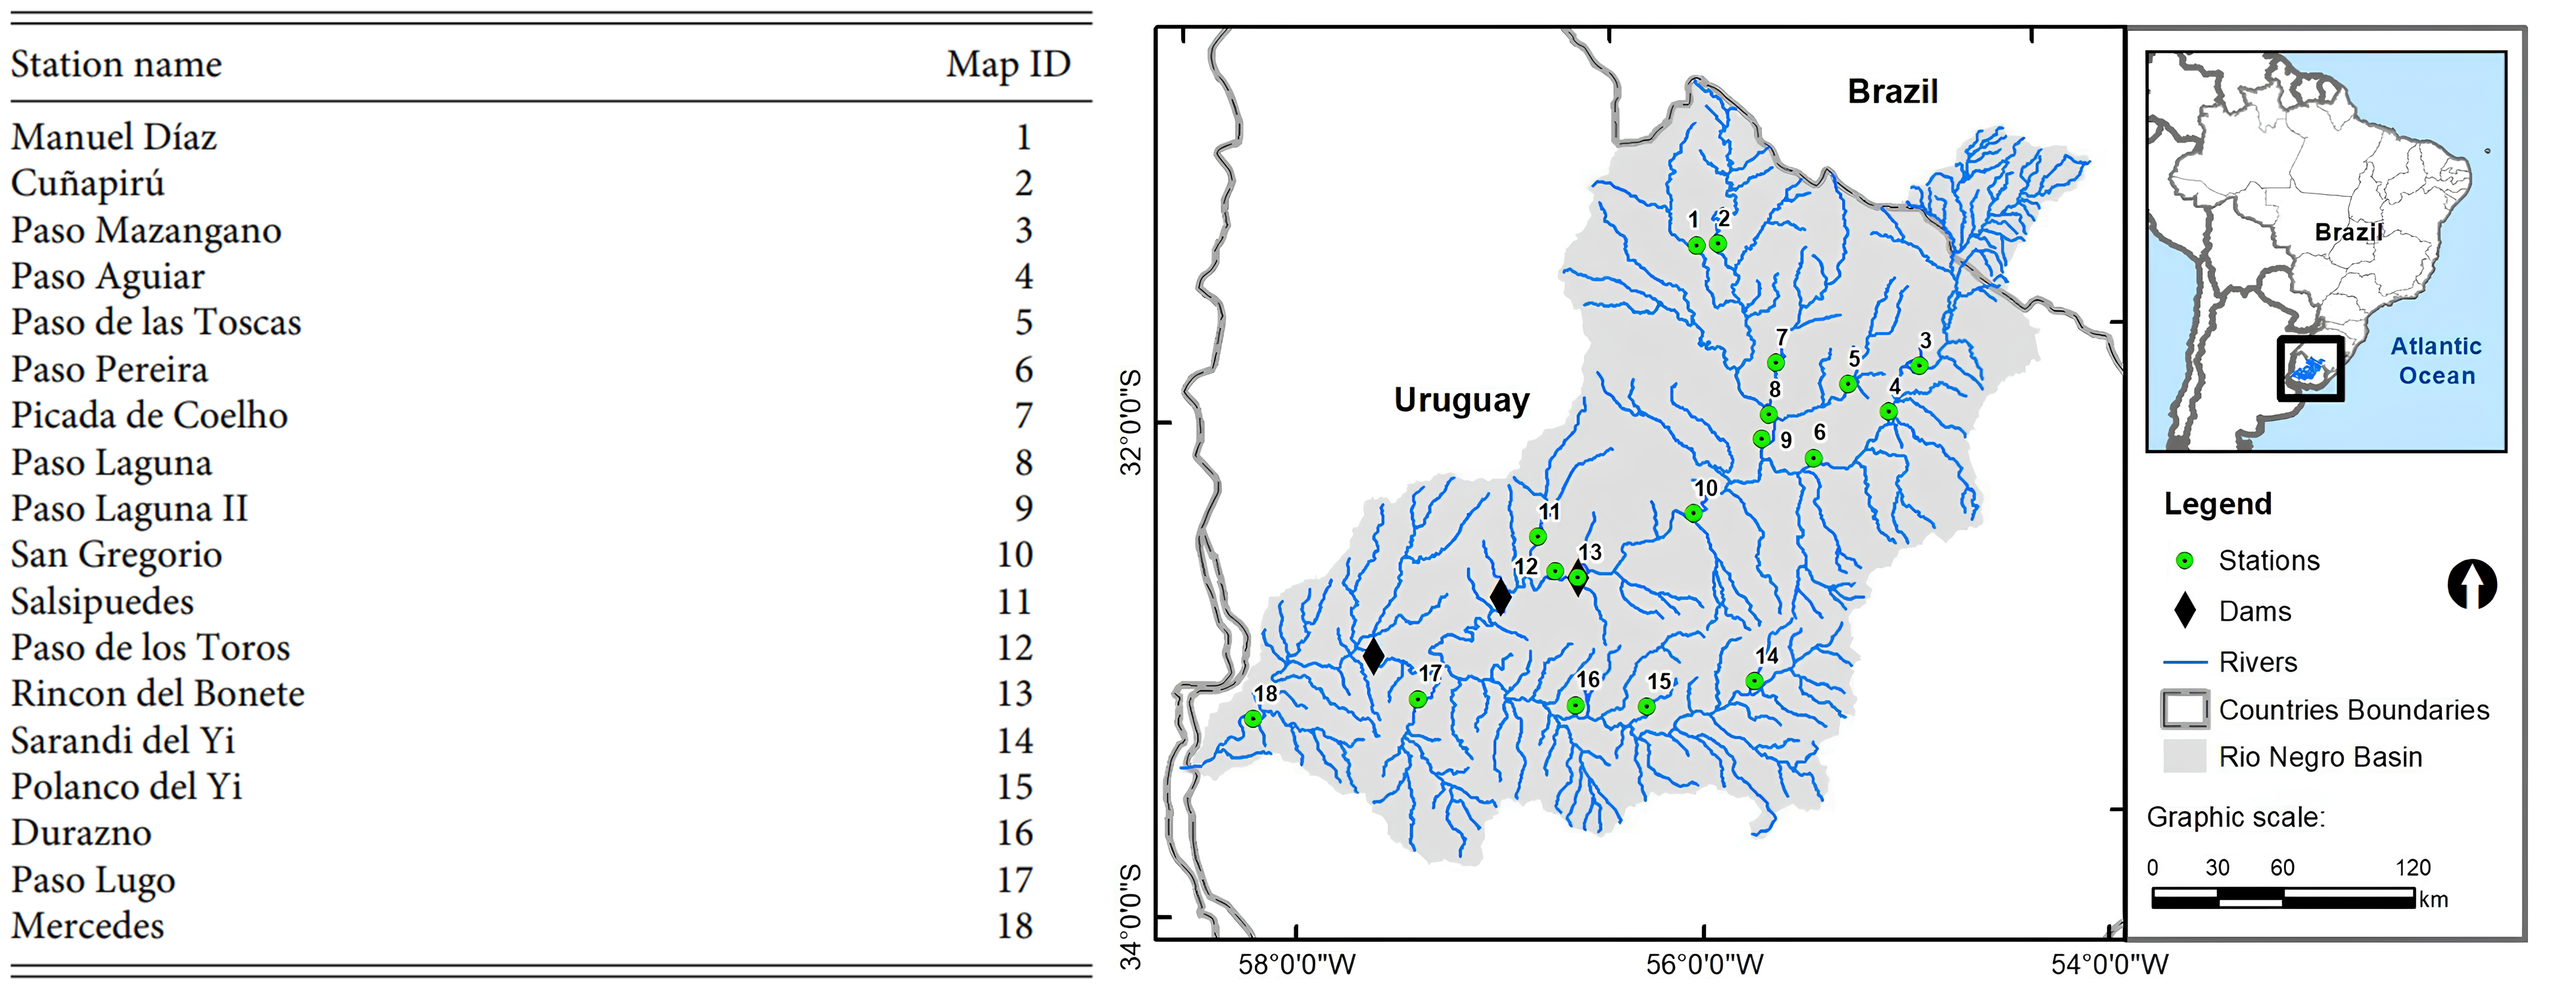

---

# Models

In [6]:
# Multi-Layer Perceptron (MLP) for river level prediction with 18 input features
class RiverMLP(nn.Module):
    def __init__(self):
        super(RiverMLP, self).__init__()
        # Network architecture:
        self.hidden = nn.Linear(18, 36)   # First hidden layer: 18 inputs → 36 neurons
        self.midle = nn.Linear(36, 36)    # Second hidden layer: 36 → 36 neurons (bottleneck)
        self.output = nn.Linear(36, 1)    # Output layer: 36 → 1 (regression output)

    def forward(self, x):
        # Forward pass with ReLU activations:
        x = torch.relu(self.hidden(x))    # Non-linear transformation
        x = torch.relu(self.midle(x))     # Additional non-linearity
        x = self.output(x)                # Final linear projection
        return x


In [7]:
# Specialized MLP for Bonete river prediction with reduced input features (11)
class RiverMLP_Bonete(nn.Module):
    def __init__(self):
        super(RiverMLP_Bonete, self).__init__()
        # Expanded architecture for 11 inputs:
        self.hidden = nn.Linear(11, 22)   # First hidden layer: 11 → 22 neurons
        self.midle = nn.Linear(22, 44)    # Second hidden layer: 22 → 44 neurons
        self.output = nn.Linear(44, 1)    # Output layer: 44 → 1

    def forward(self, x):
        # Forward pass with ReLU activations:
        x = torch.relu(self.hidden(x))    # Non-linear transformation
        x = torch.relu(self.midle(x))     # Additional non-linearity
        x = self.output(x)                # Final linear projection
        return x

In [8]:
# Simplified MLP architecture (single hidden layer)
class MLP_Johan(nn.Module):
    def __init__(self):
        super(MLP_Johan, self).__init__()
        # Minimalist architecture:
        self.hidden = nn.Linear(18, 18)   # Single hidden layer: 18 → 18 neurons
        self.output = nn.Linear(18, 1)    # Output layer: 18 → 1

    def forward(self, x):
        # Forward pass with single non-linearity:
        x = torch.relu(self.hidden(x))    # Non-linear transformation
        x = self.output(x)                # Linear output
        return x

In [9]:
# Optimized MLP architecture with hyperparameters tuned by Optuna
class OPTUNA_MLP(nn.Module):
    def __init__(self):
        super(OPTUNA_MLP, self).__init__()
        # Network architecture based on Optuna optimization results:
        self.hidden = nn.Linear(18, 112)  # Expanded first layer: 18 inputs → 112 neurons (Optuna suggested 112)
        self.midle = nn.Linear(112, 36)   # Bottleneck layer: 112 → 36 neurons
        self.output = nn.Linear(36, 1)     # Regression output: 36 → 1

    def forward(self, x):
        # Forward pass with ReLU activations:
        x = torch.relu(self.hidden(x))    # Non-linear transformation with expanded capacity
        x = torch.relu(self.midle(x))      # Dimensionality reduction with non-linearity
        x = self.output(x)                # Final linear projection
        return x

# Best hyperparameters found by Optuna:
# {'hidden_neurons': 112,               # Optimal neurons in first hidden layer
#  'lr': 0.01269463286830451,          # Learning rate for AdamW optimizer
#  'gamma': 0.9764106389992231,         # Multiplicative factor for learning rate decay
#  'step_size': 10}                    # Steps between learning rate updates

# Implementation suggestion for optimizer (commented out):
# optimizer = optim.AdamW(model.parameters(), lr=0.0306)       # Alternative learning rate
# scheduler = StepLR(optimizer, step_size=5, gamma=0.9826)    # Alternative scheduler config

# Initialize the model, loss function, optimizer, and scheduler

In [10]:
# Initialize model and training components
model = RiverMLP()  # Instantiate the MLP model
criterion = nn.MSELoss()  # Mean Squared Error loss function

# Hyperparameters (optimized by Optuna)
lr = 0.01269463286830451  # Learning rate for 1-day forecast (6-day forecast would use 0.001269...)
step_size = 10  # Scheduler step size (in epochs)
gamma = 0.9764106389992231  # Learning rate decay factor
epochs = 200  # Training epochs (400 for 6-day forecast)

# Configure optimizer (AdamW) and learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

# Metric tracking containers
loss_history = []  # Training loss
val_loss_history = []  # Validation loss
mae_history = []  # Mean Absolute Error
mse_history = []  # Mean Squared Error
rmse_history = []  # Root Mean Squared Error
r2_history = []  # R-squared
nse_history = []  # Nash-Sutcliffe Efficiency
pb_history = []  # Percent Bias
ve_history = []  # Volume Error

# Model checkpointing
best_val_mae = float('inf')  # Initialize with worst possible value
best_model_path = f"best_model_{selected_river}_MLP_shift_{MLP_shift}Day.pth"  # Dynamic filename

# Training loop
for epoch in range(epochs):
    model.train()  # Set model to training mode

    # Forward pass
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Backpropagation
    optimizer.zero_grad()  # Clear gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update weights

    # Learning rate scheduling
    scheduler.step()

    # Validation phase
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        val_predictions = model(X_val)
        val_loss = criterion(val_predictions, y_val)

        # Reverse normalization for metric calculation
        val_predictions_unscaled = scaler_y.inverse_transform(val_predictions.numpy())
        y_val_unscaled = scaler_y.inverse_transform(y_val.numpy())

        # Calculate comprehensive metrics
        mae = mean_absolute_error(y_val_unscaled, val_predictions_unscaled)
        mse = mean_squared_error(y_val_unscaled, val_predictions_unscaled)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val_unscaled, val_predictions_unscaled)
        nse = 1 - (np.sum((y_val_unscaled - val_predictions_unscaled) ** 2) / \
                np.sum((y_val_unscaled - np.mean(y_val_unscaled)) ** 2))
        pb = 100 * np.sum(val_predictions_unscaled - y_val_unscaled) / np.sum(y_val_unscaled)
        ve = 1 - abs(np.sum(y_val_unscaled) - np.sum(val_predictions_unscaled)) / np.sum(y_val_unscaled)

    # Store metrics
    loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())
    mae_history.append(mae)
    mse_history.append(mse)
    rmse_history.append(rmse)
    r2_history.append(r2)
    nse_history.append(nse)
    pb_history.append(pb)
    ve_history.append(ve)

    # Save best model checkpoint
    if mae < best_val_mae:
        best_val_mae = mae
        torch.save(model.state_dict(), best_model_path)
        print(f"🔹 Best model saved at epoch {epoch+1} with Val MAE: {best_val_mae:.4f}")

    # Progress reporting
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], "
              f"Loss: {loss.item():.4f}, "
              f"LR: {scheduler.get_last_lr()[0]:.6f}, "
              f"MAE: {mae:.4f}, "
              f"MSE: {mse:.4f}, "
              f"RMSE: {rmse:.4f}, "
              f"R²: {r2:.4f}, "
              f"NSE: {nse:.4f}, "
              f"PB: {pb:.4f}, "
              f"VE: {ve:.4f}")

# Finalization
print("\n✅ Training complete. Loading the best model...")
model.load_state_dict(torch.load(best_model_path))  # Load optimal weights
model.eval()  # Set to evaluation mode

# Package metrics for analysis
metrics_history = {
    'Loss': loss_history,
    'Val Loss': val_loss_history,
    'MAE': mae_history,
    'MSE': mse_history,
    'RMSE': rmse_history,
    'R2': r2_history,
    'NSE': nse_history,
    'PB': pb_history,
    'VE': ve_history
}

🔹 Best model saved at epoch 1 with Val MAE: 1.9366
🔹 Best model saved at epoch 2 with Val MAE: 0.8496
🔹 Best model saved at epoch 5 with Val MAE: 0.6330
🔹 Best model saved at epoch 6 with Val MAE: 0.5179
🔹 Best model saved at epoch 12 with Val MAE: 0.4941
🔹 Best model saved at epoch 17 with Val MAE: 0.4888
🔹 Best model saved at epoch 18 with Val MAE: 0.4733
Epoch [20/200], Loss: 0.0073, LR: 0.012103, MAE: 0.5246, MSE: 0.5145, RMSE: 0.7173, R²: 0.6306, NSE: 0.6306, PB: -15.3285, VE: 0.8467
🔹 Best model saved at epoch 24 with Val MAE: 0.4642
🔹 Best model saved at epoch 25 with Val MAE: 0.4487
🔹 Best model saved at epoch 29 with Val MAE: 0.4440
🔹 Best model saved at epoch 30 with Val MAE: 0.4324
🔹 Best model saved at epoch 36 with Val MAE: 0.4243
🔹 Best model saved at epoch 37 with Val MAE: 0.4122
🔹 Best model saved at epoch 38 with Val MAE: 0.4087
🔹 Best model saved at epoch 39 with Val MAE: 0.4078
🔹 Best model saved at epoch 40 with Val MAE: 0.4027
Epoch [40/200], Loss: 0.0040, LR: 0.01

# Result's

## Graph Metrics History Plot - Validation Data

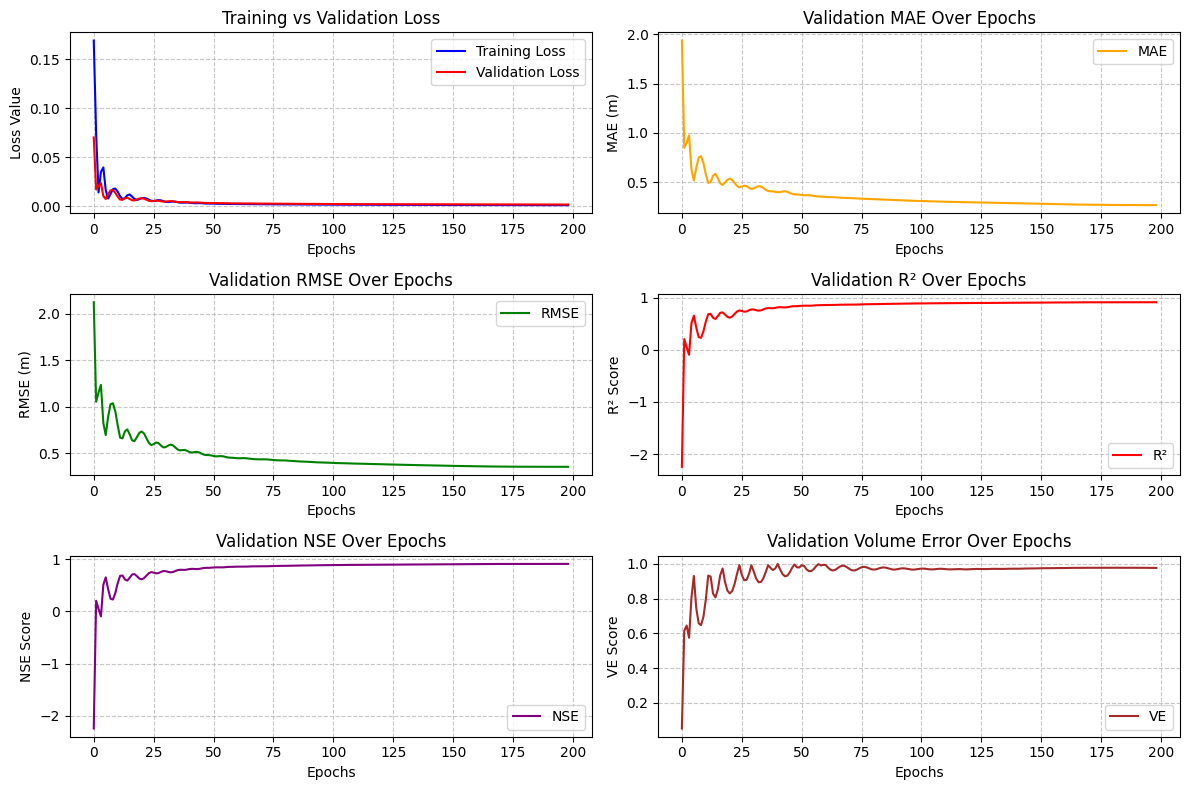

In [11]:
# Create a figure for plotting metrics with specified size (12x8 inches)
plt.figure(figsize=(12, 8))

# Plot 1: Training and Validation Loss
plt.subplot(3, 2, 1)  # 3 rows, 2 columns, position 1
plt.plot(metrics_history['Loss'][:-1], label='Training Loss', color='blue')
plt.plot(metrics_history['Val Loss'][:-1], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Mean Absolute Error (MAE)
plt.subplot(3, 2, 2)  # Position 2
plt.plot(metrics_history['MAE'][:-1], label='MAE', color='orange')
plt.xlabel('Epochs')
plt.ylabel('MAE (m)')  # Assuming water level in meters
plt.title('Validation MAE Over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 3: Root Mean Squared Error (RMSE)
plt.subplot(3, 2, 3)  # Position 3
plt.plot(metrics_history['RMSE'][:-1], label='RMSE', color='green')
plt.xlabel('Epochs')
plt.ylabel('RMSE (m)')
plt.title('Validation RMSE Over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 4: R-squared (R²)
plt.subplot(3, 2, 4)  # Position 4
plt.plot(metrics_history['R2'][:-1], label='R²', color='red')
plt.xlabel('Epochs')
plt.ylabel('R² Score')
plt.title('Validation R² Over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 5: Nash-Sutcliffe Efficiency (NSE)
plt.subplot(3, 2, 5)  # Position 5
plt.plot(metrics_history['NSE'][:-1], label='NSE', color='purple')
plt.xlabel('Epochs')
plt.ylabel('NSE Score')
plt.title('Validation NSE Over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 6: Volume Error (VE)
plt.subplot(3, 2, 6)  # Position 6
plt.plot(metrics_history['VE'][:-1], label='VE', color='brown')
plt.xlabel('Epochs')
plt.ylabel('VE Score')
plt.title('Validation Volume Error Over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust subplot spacing to prevent overlap
plt.tight_layout()

# Display the complete figure
plt.show()

##### best_metrics - validation data

In [12]:
# Calculate optimal performance metrics and their corresponding epochs
best_metrics = {
    "Metric": ["Loss", "MAE", "RMSE", "R²", "NSE", "VE"],
    "Best Value": [
        min(metrics_history["Loss"]),   # Minimum loss value
        min(metrics_history["MAE"]),    # Minimum Mean Absolute Error
        min(metrics_history["RMSE"]),   # Minimum Root Mean Squared Error
        max(metrics_history["R2"]),     # Maximum R-squared (coefficient of determination)
        max(metrics_history["NSE"]),    # Maximum Nash-Sutcliffe Efficiency
        max(metrics_history["VE"])      # Maximum Volume Error
    ],
    "Epoch": [
        # Find epoch number where each metric achieved its best value
        metrics_history["Loss"].index(min(metrics_history["Loss"])) + 1,   # +1 converts to 1-based indexing
        metrics_history["MAE"].index(min(metrics_history["MAE"])) + 1,
        metrics_history["RMSE"].index(min(metrics_history["RMSE"])) + 1,
        metrics_history["R2"].index(max(metrics_history["R2"])) + 1,
        metrics_history["NSE"].index(max(metrics_history["NSE"])) + 1,
        metrics_history["VE"].index(max(metrics_history["VE"])) + 1
    ],
    "Interpretation": [
        "Lower is better",
        "Lower is better (meters)",
        "Lower is better (meters)",
        "Higher is better (0-1 scale)",
        "Higher is better (ideal=1)",
        "Higher is better (1=perfect volume match)"
    ]
}

# Convert to DataFrame for better visualization
best_metrics_df = pd.DataFrame(best_metrics)

# Display formatted results
print("\n🏆 Best Model Performance Metrics (Validation Set) \n")
print(best_metrics_df.to_string(index=False, justify='center'))

# Additional statistical summary
print("\n📊 Key Statistics:")
print(f"- Training converged after {best_metrics_df['Epoch'].median()} epochs (median)")
print(f"- Best MAE: {min(metrics_history['MAE']):.4f} m achieved at epoch {best_metrics_df.loc[best_metrics_df['Metric'] == 'MAE', 'Epoch'].values[0]}")
print(f"- Peak NSE: {max(metrics_history['NSE']):.4f} (closer to 1 indicates better model)")


🏆 Best Model Performance Metrics (Validation Set) 

Metric  Best Value  Epoch               Interpretation             
 Loss    0.001294   200                             Lower is better
  MAE    0.268092   199                    Lower is better (meters)
 RMSE    0.351927   191                    Lower is better (meters)
   R²    0.911072   191                Higher is better (0-1 scale)
  NSE    0.911072   191                  Higher is better (ideal=1)
   VE    0.999836    41   Higher is better (1=perfect volume match)

📊 Key Statistics:
- Training converged after 191.0 epochs (median)
- Best MAE: 0.2681 m achieved at epoch 199
- Peak NSE: 0.9111 (closer to 1 indicates better model)


## Metrics History

### Validation Data

In [13]:
# Model Evaluation on Test Set
model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient calculation for efficiency
    # Generate predictions
    test_predictions = model(X_test)
    # Reverse normalization to original scale
    test_predictions = scaler_y.inverse_transform(test_predictions.numpy())
    actual_values = scaler_y.inverse_transform(y_test.numpy())

# Create comparison DataFrame
results_df = pd.DataFrame({
    'Predicted Values (m)': test_predictions.flatten(),
    'Actual Values (m)': actual_values.flatten(),
    'Absolute Error (m)': np.abs(test_predictions.flatten() - actual_values.flatten())
})

# Display first 10 rows of results
print("\n🔍 Prediction vs Actual Values (First 10 Samples):")
print(results_df.head(10).to_string(index=False, float_format="%.4f"))

# Calculate final metrics from validation history
best_epoch = metrics_history["MAE"].index(min(metrics_history["MAE"])) + 1
final_metrics = {
    "Loss": metrics_history["Loss"][-1],
    "MAE": metrics_history["MAE"][-1],
    "MSE": metrics_history["MSE"][-1],
    "RMSE": metrics_history["RMSE"][-1],
    "R²": metrics_history["R2"][-1],
    "NSE": metrics_history["NSE"][-1],
    "PB": metrics_history["PB"][-1],
    "VE": metrics_history["VE"][-1]
}

# Print comprehensive evaluation report
print("\n" + "="*60)
print(f"🌊 FINAL MODEL EVALUATION: {selected_river} (MLP_shift_{MLP_shift}Day)")
print("="*60)
print(f"📍 Best Epoch: {best_epoch}/{epochs}")
print(f"⚙️  Training Configuration:")
print(f"   - Learning Rate: {lr:.6f}")
print(f"   - Scheduler: StepLR(gamma={gamma}, step_size={step_size})")
print(f"   - Optimizer: {optimizer.__class__.__name__}")

print("\n📊 Validation Metrics:")
print("-"*40)
print(f"Loss: {final_metrics['Loss']:.4f}")
print(f"MAE: {final_metrics['MAE']:.4f} m")
print(f"RMSE: {final_metrics['RMSE']:.4f} m")
print(f"R²: {final_metrics['R²']:.4f} (1.0 = perfect fit)")
print(f"NSE: {final_metrics['NSE']:.4f} (1.0 = perfect model)")
print(f"Percent Bias: {final_metrics['PB']:.2f}%")
print(f"Volume Efficiency: {final_metrics['VE']:.4f}")

print("\n" + "="*60)
print("💡 Interpretation Guide:")
print("- MAE/RMSE: Lower is better (in meters)")
print("- R²: 0-1 scale (higher = better fit)")
print("- NSE: >0.5 acceptable, >0.75 good")
print("- PB: Closer to 0% is better")
print("- VE: Closer to 1 is better")
print("="*60)


🔍 Prediction vs Actual Values (First 10 Samples):
 Predicted Values (m)  Actual Values (m)  Absolute Error (m)
               1.7248             1.3500              0.3748
               1.4592             1.6800              0.2208
               1.6262             2.1000              0.4738
               2.0310             2.5000              0.4690
               2.4027             2.1000              0.3027
               2.2525             2.1400              0.1125
               2.1002             1.7000              0.4002
               1.6574             1.7000              0.0426
               1.5798             1.7500              0.1702
               1.6136             1.5500              0.0636

🌊 FINAL MODEL EVALUATION: Mercedes_level (MLP_shift_1Day)
📍 Best Epoch: 199/200
⚙️  Training Configuration:
   - Learning Rate: 0.012695
   - Scheduler: StepLR(gamma=0.9764106389992231, step_size=10)
   - Optimizer: AdamW

📊 Validation Metrics:
--------------------------------

### Test Data

In [14]:
def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive evaluation metrics for regression tasks.

    Args:
        y_true (array): Ground truth values
        y_pred (array): Predicted values

    Returns:
        tuple: (mae, mse, rmse, r2, nse, ve) - various regression metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    ve = 1 - abs(np.sum(y_true) - np.sum(y_pred)) / np.sum(y_true)
    return mae, mse, rmse, r2, nse, ve

# Create DataFrame with predictions and actual values
results = pd.DataFrame({
    'Predicted (m)': test_predictions.flatten(),
    'Actual (m)': actual_values.flatten(),
    'Error (m)': test_predictions.flatten() - actual_values.flatten()
})

# Calculate cumulative metrics over time
metrics_history = {
    'Day': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R²': [],
    'NSE': [],
    'VE': []
}

for day in range(1, len(results) + 1):
    y_true = results['Actual (m)'][:day].values
    y_pred = results['Predicted (m)'][:day].values

    mae, mse, rmse, r2, nse, ve = calculate_metrics(y_true, y_pred)

    metrics_history['Day'].append(day)
    metrics_history['MAE'].append(mae)
    metrics_history['MSE'].append(mse)
    metrics_history['RMSE'].append(rmse)
    metrics_history['R²'].append(r2)
    metrics_history['NSE'].append(nse)
    metrics_history['VE'].append(ve)

# Get final metrics
final_mae, final_mse, final_rmse, final_r2, final_nse, final_ve = calculate_metrics(
    results['Actual (m)'], results['Predicted (m)']
)

# Print comprehensive evaluation report
print("\n" + "═" * 70)
print(f"🌊 FINAL MODEL EVALUATION: {selected_river} (MLP_shift_{MLP_shift}Day)")
print("═" * 70)
print(f"📅 Training Duration: {epochs} epochs (best at epoch {best_epoch})")
print(f"⚙️  Training Configuration:")
print(f"   • Learning Rate: {lr:.6f}")
print(f"   • Scheduler: StepLR(γ={gamma}, step={step_size})")
print(f"   • Optimizer: {optimizer.__class__.__name__}")

print("\n" + "─" * 70)
print("📊 Test Set Performance Metrics:")
print("─" * 70)
print(f"{'Day':<5} | {'MAE (m)':>8} | {'MSE':>8} | {'RMSE (m)':>8} | {'R²':>6} | {'NSE':>6} | {'VE':>6}")
print("-" * 70)
print(f"{MLP_shift:<5} | {final_mae:>8.4f} | {final_mse:>8.4f} | {final_rmse:>8.4f} | {final_r2:>6.4f} | {final_nse:>6.4f} | {final_ve:>6.4f}")

print("\n" + "═" * 70)
print("💡 Interpretation Guide:")
print("- MAE/RMSE: Lower is better (in meters)")
print("- MSE: Lower is better (squared units)")
print("- R²: 0-1 scale (1 = perfect fit)")
print("- NSE: >0.5 acceptable, >0.75 good")
print("- VE: Closer to 1 is better (volume conservation)")
print("═" * 70)

# Optionally show first few predictions
print("\n🔍 Sample Predictions:")
print(results.head().to_string(index=False, float_format="%.4f"))

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
<ipython-input-14-15f803c72984>:15: RuntimeWarning: divide by zero encountered in scalar divide
  nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)



══════════════════════════════════════════════════════════════════════
🌊 FINAL MODEL EVALUATION: Mercedes_level (MLP_shift_1Day)
══════════════════════════════════════════════════════════════════════
📅 Training Duration: 200 epochs (best at epoch 199)
⚙️  Training Configuration:
   • Learning Rate: 0.012695
   • Scheduler: StepLR(γ=0.9764106389992231, step=10)
   • Optimizer: AdamW

──────────────────────────────────────────────────────────────────────
📊 Test Set Performance Metrics:
──────────────────────────────────────────────────────────────────────
Day   |  MAE (m) |      MSE | RMSE (m) |     R² |    NSE |     VE
----------------------------------------------------------------------
1     |   0.2659 |   0.1246 |   0.3530 | 0.9080 | 0.9080 | 0.9967

══════════════════════════════════════════════════════════════════════
💡 Interpretation Guide:
- MAE/RMSE: Lower is better (in meters)
- MSE: Lower is better (squared units)
- R²: 0-1 scale (1 = perfect fit)
- NSE: >0.5 acceptable, >0.

## Graph Plot's:

### Graph Plot - Predictions vs Actual Values - All Data

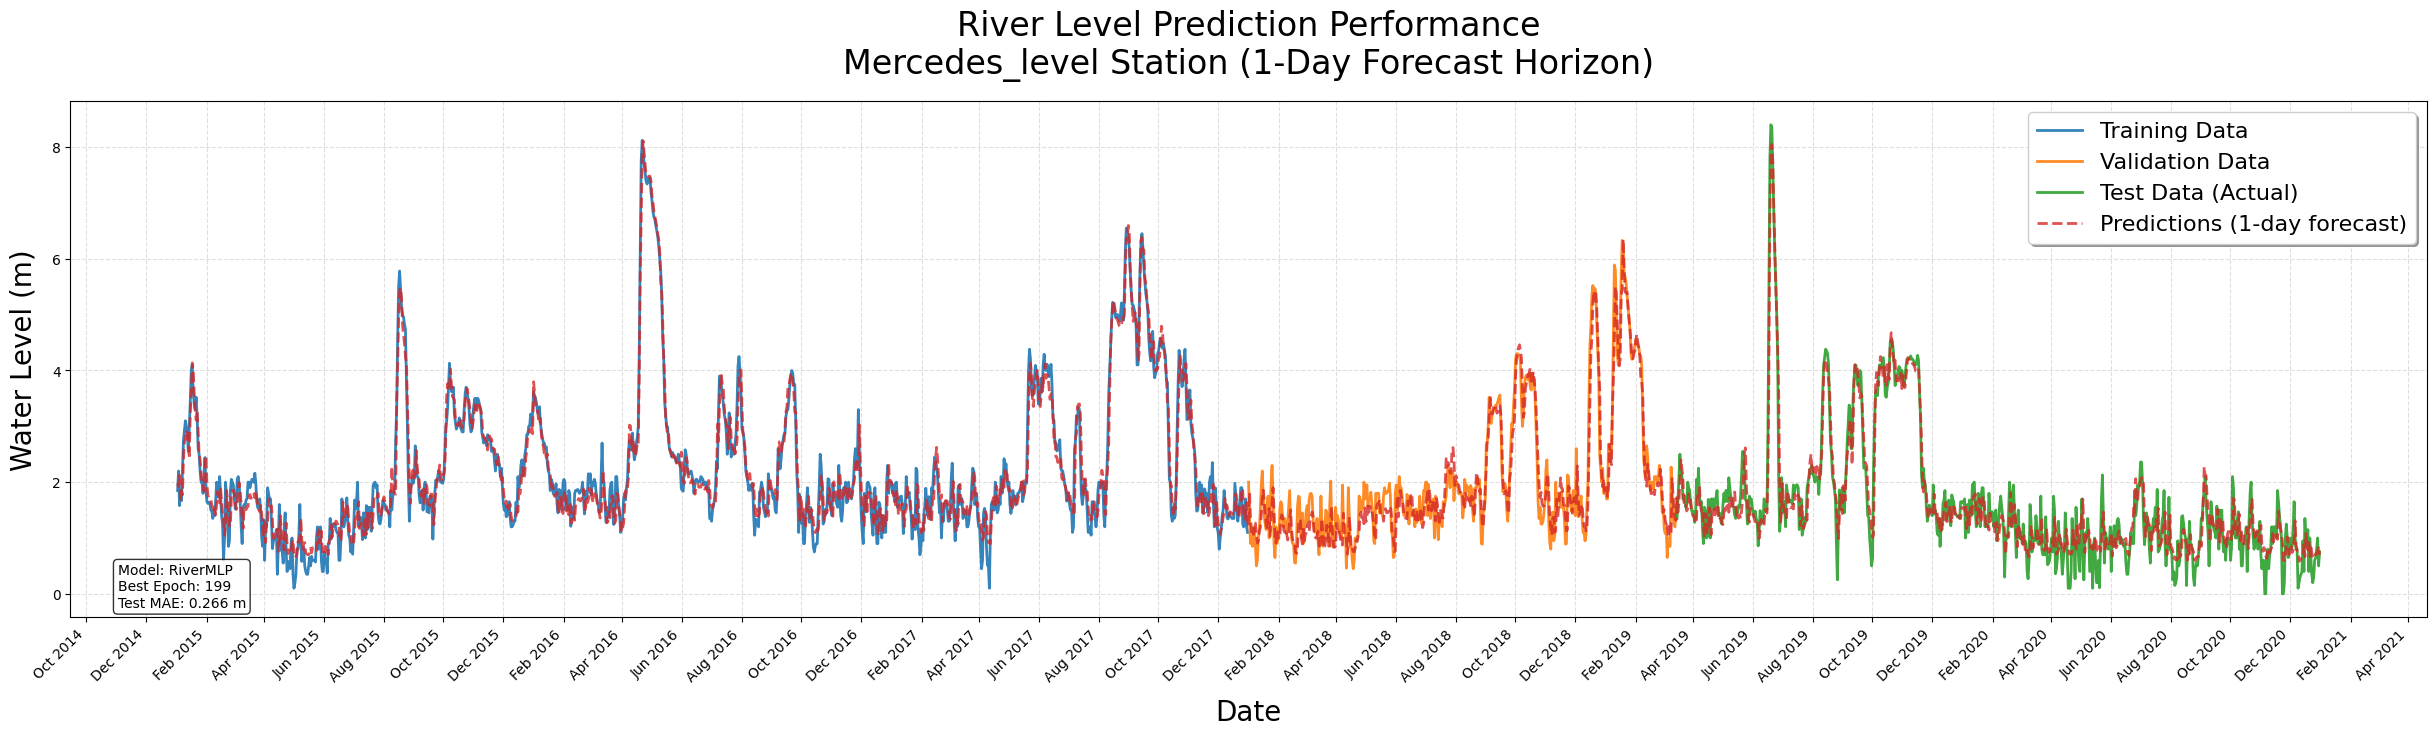

In [15]:
# Load and preprocess data
data_file = '/content/Rio Negro_level - date_18.csv'
data = pd.read_csv(data_file)

# Convert date column with error handling
data['date'] = pd.to_datetime(data['date'], format="%d/%m/%Y %H:%M", errors='coerce')

# Handle potential parsing errors
if data['date'].isnull().any():
    print(f"Warning: {data['date'].isnull().sum()} dates couldn't be parsed")

# Align time with predictions (accounting for forecast shift)
time_series = data['date'].iloc[MLP_shift:].reset_index(drop=True)

# Prepare features (excluding date/days columns)
features = data.drop(columns=['date', 'days'], errors='ignore').values[:-1]  # -1 to match MLP_shift

# Inverse transform normalized data
y_train_actual = scaler_y.inverse_transform(y_train.numpy().reshape(-1, 1)).flatten()
y_val_actual = scaler_y.inverse_transform(y_val.numpy().reshape(-1, 1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()

# Align time segments with data splits
time_train = time_series.iloc[:len(y_train_actual)]
time_val = time_series.iloc[len(y_train_actual):len(y_train_actual)+len(y_val_actual)]
time_test = time_series.iloc[len(y_train_actual)+len(y_val_actual):len(y_train_actual)+len(y_val_actual)+len(y_test_actual)]

# Generate full predictions
model.eval()
with torch.no_grad():
    # Process all features at once
    features_normalized = scaler_X.transform(features)
    full_predictions = model(torch.tensor(features_normalized, dtype=torch.float32))
    full_predictions = scaler_y.inverse_transform(full_predictions.numpy().reshape(-1, 1)).flatten()

# Create visualization
plt.figure(figsize=(25, 8))

# Plot actual data
plt.plot(time_train, y_train_actual, label='Training Data', color='#1f77b4', linewidth=2, alpha=0.9)
plt.plot(time_val, y_val_actual, label='Validation Data', color='#ff7f0e', linewidth=2, alpha=0.9)
plt.plot(time_test, y_test_actual, label='Test Data (Actual)', color='#2ca02c', linewidth=2, alpha=0.9)

# Plot predictions
plt.plot(time_series, full_predictions[:len(time_series)],
         label=f'Predictions ({MLP_shift}-day forecast)',
         color='#d62728', linestyle='--', linewidth=2, alpha=0.8)

# Format x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate(rotation=45)

# Add visual elements
plt.title(f'River Level Prediction Performance\n{selected_river} Station ({MLP_shift}-Day Forecast Horizon)',
          fontsize=24, pad=20)
plt.xlabel('Date', fontsize=20, labelpad=10)
plt.ylabel('Water Level (m)', fontsize=20, labelpad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

# Add secondary elements
plt.legend(fontsize=16, framealpha=1, shadow=True)
plt.tight_layout(pad=3.0)

# Add annotation with model info
plt.annotate(f'Model: {model.__class__.__name__}\nBest Epoch: {best_epoch}\nTest MAE: {final_mae:.3f} m',
             xy=(0.02, 0.02), xycoords='axes fraction',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

### Graph Plot - Predictions vs Actual Values - Test Data

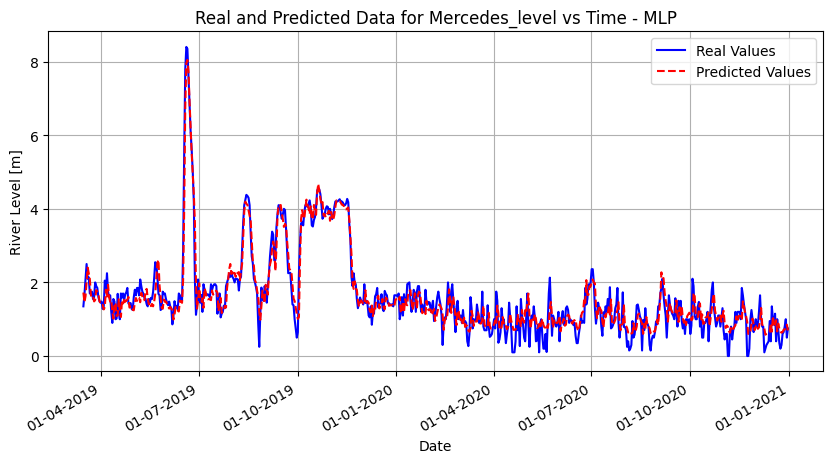

In [16]:
# Load the CSV file containing river level data with timestamps
data_file = '/content/Rio Negro_level - date_18.csv'
data_df = pd.read_csv(data_file)

# Convert the 'date' column from string to datetime format
# Using exact format specification for faster parsing
# 'coerce' handles invalid dates by converting them to NaT (Not a Time)
data_df['date'] = pd.to_datetime(data_df['date'], format="%d/%m/%Y %H:%M", errors='coerce')

# Prepare time data for plotting by selecting dates corresponding to test set:
# - tempo_size gets the number of samples in test set
# - tempo_test selects the last N dates from dataframe (N = test set size)
tempo_size = len(X_test)  # Get length of test features
tempo_test = data_df['date'].iloc[-tempo_size:]  # Slice last N dates matching test set size

# Create time series comparison plot:
plt.figure(figsize=(10, 5))  # Set figure size (width, height in inches)

# Plot actual measured values:
# - tempo_test provides x-axis dates
# - actual_values contains ground truth water levels
# - flattened to 1D array for plotting
plt.plot(tempo_test, actual_values.flatten(),
         label='Real Values',  # Legend label
         color='blue')  # Solid blue line for actual values

# Plot model predictions:
# - Same x-axis as actual values
# - test_predictions contains model outputs
# - Dashed red line distinguishes from actual
plt.plot(tempo_test, test_predictions.flatten(),
         label='Predicted Values',
         color='red',
         linestyle='dashed')  # Dashed line style

# Configure plot labels and decorations:
plt.title(f'Real and Predicted Data for {river} vs Time - MLP')  # Dynamic title with river name
plt.xlabel('Date')  # X-axis label
plt.ylabel('River Level [m]')  # Y-axis label with units
plt.grid(True)  # Enable grid lines
plt.legend()  # Show plot legend with line labels

# Format date display on x-axis:
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))  # Day-Month-Year format
plt.gcf().autofmt_xdate()  # Auto-rotate dates for better readability

# Display the complete figure
plt.show()

### Graph Plot - Predictions vs Actual Values - Test Data + absolute_errors

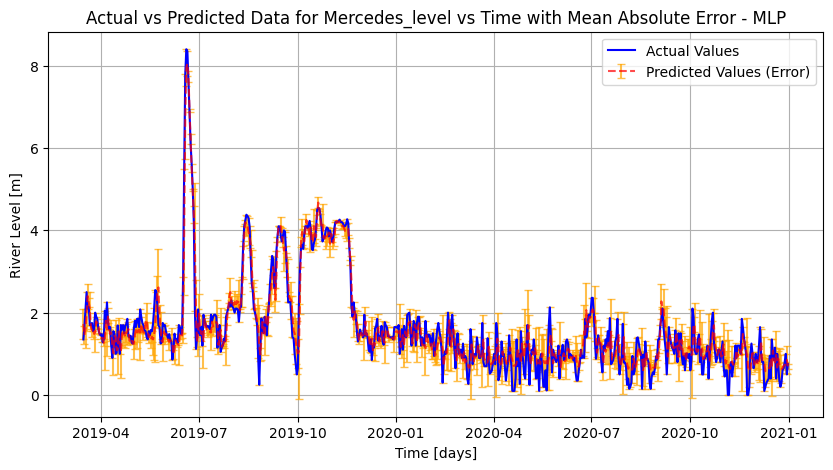

In [17]:
# Calculate the absolute errors between actual and predicted values
# real_values contains the ground truth measurements (inverse transformed from y_test)
real_values = y_test_actual  # Actual river level measurements from test set
absolute_errors = np.abs(real_values - test_predictions.flatten())  # Absolute differences between actual and predicted values

# Create Plot 3: Comparison of actual vs predicted values with error bars
plt.figure(figsize=(10, 5))  # Initialize a 10x5 inch figure

# Plot predicted values with error bars showing the absolute errors:
# - tempo_test: x-axis (time/dates)
# - test_predictions.flatten(): y-axis (model predictions)
# - yerr=absolute_errors: vertical error bars showing prediction errors
# - label: legend label for predicted values
# - linestyle='dashed': makes predictions visually distinct from actuals
# - color='red': color for prediction line
# - ecolor='orange': color for error bars
# - alpha=0.7: transparency level
# - capsize=3: size of error bar caps
plt.errorbar(tempo_test,
             test_predictions.flatten(),
             yerr=absolute_errors,
             label='Predicted Values (Error)',
             linestyle='dashed',
             color='red',
             ecolor='orange',
             alpha=0.7,
             capsize=3)

# Plot actual measured values:
# - tempo_test: same x-axis as predictions
# - real_values: ground truth measurements
# - label: legend label for actual values
# - color='blue': color for actual values line
plt.plot(tempo_test,
         real_values,
         label='Actual Values',
         color='blue')

# Configure plot title and labels:
plt.title(f'Actual vs Predicted Data for {river} vs Time with Mean Absolute Error - MLP')  # Dynamic title with river name
plt.xlabel('Time [days]')  # X-axis label
plt.ylabel('River Level [m]')  # Y-axis label with units

# Add plot decorations:
plt.grid(True)  # Show grid lines
plt.legend()  # Display legend with both actual and predicted labels

# Display the plot
plt.show()